# Khắc phục lỗi: Cài đặt TensorFlow
Vì môi trường chạy Jupyter Notebook của bạn đang sử dụng một phiên bản Python khác chưa có TensorFlow, chúng ta cần cài đặt nó trực tiếp ngay bên trong Notebook bằng lệnh dưới đây. Hãy chạy ô này trước nhé!

In [1]:
!pip install --no-cache-dir tensorflow
!pip install scikit-learn pandas numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Mô hình Deep Learning: LSTM
Trong phần này, chúng ta sẽ xây dựng mạng nơ-ron hồi quy (RNN) với kiến trúc Long Short-Term Memory (LSTM).

**Xử lý dữ liệu Sequence (Chuỗi):**
Không giống như XGBoost hay SARIMAX, LSTM yêu cầu dữ liệu phải được định dạng dưới dạng chuỗi 3 chiều: `(số_lượng_mẫu, số_bước_thời_gian, số_features)`. Nó sẽ học từ một "khung cửa sổ thời gian" để đoán tương lai.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Đưa TensorFlow lên trước tiên để tránh lỗi DLL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Đọc dữ liệu
df = pd.read_csv('../data/processed/pm25_training_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Để huấn luyện LSTM hội tụ tốt và dễ quan sát, ta chọn dữ liệu 1 thành phố (Hà Nội)
df_hn = df[df['city'] == 'Hà Nội'].sort_values('datetime').reset_index(drop=True)

# Lựa chọn feature cốt lõi thay vì toàn bộ để tránh noise
FEATURES = ['pm25', 'temp', 'humidity', 'wind_speed', 'pressure', 'pm10']
TARGET_IDX = 0  # 'pm25' nằm ở vị trí đầu tiên (index 0) trong danh sách FEATURES

df_lstm = df_hn[FEATURES].dropna()
print(f"Số lượng dữ liệu ban đầu: {df_lstm.shape}")

TensorFlow Version: 2.21.0
Số lượng dữ liệu ban đầu: (32969, 6)


## Chuẩn hóa dữ liệu & Tạo Sequences
LSTM đặc biệt nhạy cảm với thang đo của dữ liệu, vì vậy chúng ta cần chuẩn hóa bằng `MinMaxScaler` để mọi thứ nằm trong khoảng [0, 1].

In [3]:
# Normalize dữ liệu
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_lstm.values)

# Hàm tạo sequences: 
# Mỗi mẫu sẽ dùng `seq_len` giờ trước đó làm Input (X) để dự báo PM2.5 cho 1 giờ tiếp theo làm Output (y).
SEQ_LEN = 48  # Look-back window = dùng 48 giờ trước để đoán

def create_sequences(data, seq_len, pred_len=24, target_idx=0):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i : i + seq_len])           # 48 bước thời gian x số features
        y.append(data[i + seq_len : i + seq_len + pred_len, target_idx])   # Target (PM2.5) ở giờ tiếp theo
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(data_scaled, SEQ_LEN, 24)
print(f"Kích thước tập X: {X_all.shape} (mẫu, time_steps, features)")
print(f"Kích thước tập y: {y_all.shape}")

# Chia Train/Test (80% / 20%)
split = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

print(f"Tập Train: {len(X_train)} sequences")
print(f"Tập Test:  {len(X_test)} sequences")

Kích thước tập X: (32898, 48, 6) (mẫu, time_steps, features)
Kích thước tập y: (32898, 24)
Tập Train: 26318 sequences
Tập Test:  6580 sequences


## Xây dựng và Huấn luyện mô hình LSTM
Chúng ta thiết kế mạng với 2 tầng ẩn LSTM, kẹp giữa là các tầng Dropout để hạn chế học tủ (Overfitting).

In [4]:
# Khởi tạo cấu trúc mô hình (Cập nhật tương thích với Keras 3/TensorFlow 2.16+)
model_lstm = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURES))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(24) # 24 units output for 24h forecasting
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
model_lstm.summary()

# Định nghĩa các callback để tối ưu quá trình học
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

print("Bắt đầu huấn luyện LSTM...")
history = model_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1, # Dành 10% tập train làm validation
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,528 (123.16 KB)

 Trainable params: 31,528 (123.16 KB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện LSTM...
Epoch 1/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - loss: 0.0146 - mae: 0.0872 - val_loss: 0.0141 - val_mae: 0.0797 - learning_rate: 0.0010
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - loss: 0.0097 - mae: 0.0712 - val_loss: 0.0122 - val_mae: 0.0738 - learning_rate: 0.0010
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 145ms/step - loss: 0.0090 - mae: 0.0688 - val_loss: 0.0114 - val_mae: 0.0719 - learning_rate: 0.0010
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - loss: 0.0087 - mae: 0.0673 - val_loss: 0.0116 - val_mae: 0.0721 - learning_rate: 0.0010
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - loss: 0.0083 - mae: 0.0659 - val_loss: 0.0109 - val_mae: 0.0697 - learning_rate: 0.0010
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0078 - mae: 0.0633 - val_loss: 0.0096 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - loss: 0.0074 - mae: 0.0614 - val_loss: 0.0100 - val_mae: 0.0

## Đánh giá và Đảo ngược chuẩn hóa (Inverse Transform)
Vì dữ liệu ban đầu đã bị co lại vào khoảng [0,1], chúng ta phải làm thao tác "đảo ngược" (Inverse) để có thể tính sai số thực tế tính bằng $\mu g/m^3$.

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

📊 KẾT QUẢ LSTM:
   RMSE: 22.58 µg/m³
   MAE:  15.82 µg/m³


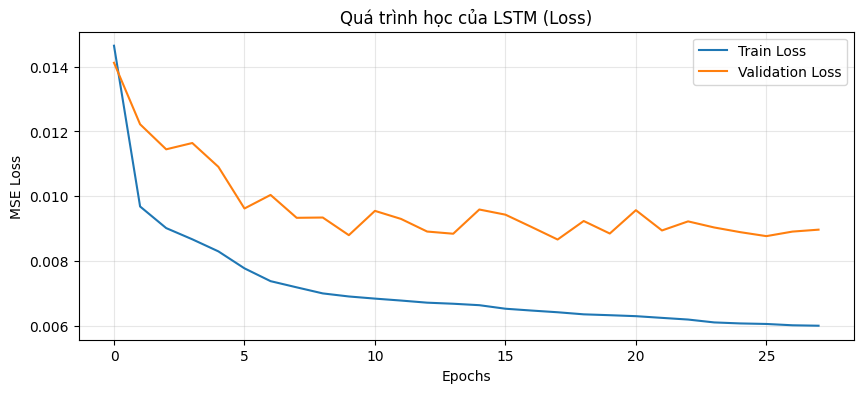

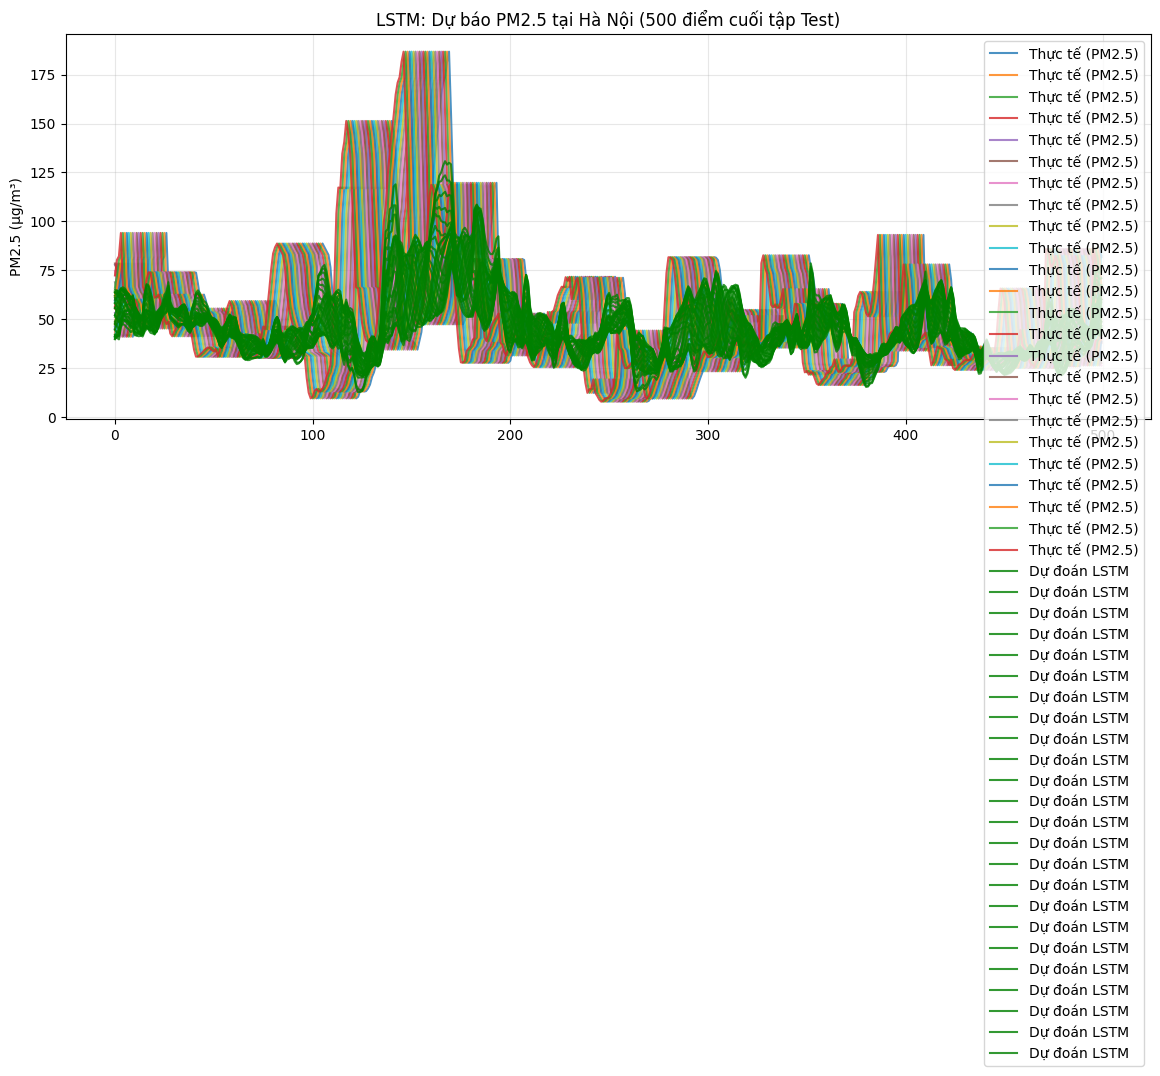

In [5]:
# Dự đoán trên tập test
y_pred_scaled = model_lstm.predict(X_test)

# Hàm đảo ngược chuẩn hóa chỉ dành cho cột Target (PM2.5)
def inverse_pm25(scaled_values, scaler, target_idx, n_features):
    N, pred_len = scaled_values.shape
    dummy = np.zeros((N * pred_len, n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    inv = scaler.inverse_transform(dummy)[:, target_idx]
    return inv.reshape(N, pred_len)


y_pred_actual = inverse_pm25(y_pred_scaled, scaler, TARGET_IDX, len(FEATURES))
y_test_actual = inverse_pm25(y_test, scaler, TARGET_IDX, len(FEATURES))

# Đánh giá sai số thực tế
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae  = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"\n📊 KẾT QUẢ LSTM:")
print(f"   RMSE: {rmse:.2f} µg/m³")
print(f"   MAE:  {mae:.2f} µg/m³")

# Vẽ biểu đồ Loss trong quá trình học
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Quá trình học của LSTM (Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Trực quan hóa dự báo (500 điểm cuối)
n_show = min(500, len(y_test_actual))
plt.figure(figsize=(14, 5))
plt.plot(range(n_show), y_test_actual[-n_show:], label='Thực tế (PM2.5)', alpha=0.8)
plt.plot(range(n_show), y_pred_actual[-n_show:], color='green', label='Dự đoán LSTM', alpha=0.8)
plt.title(f'LSTM: Dự báo PM2.5 tại Hà Nội ({n_show} điểm cuối tập Test)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()